<class 'pandas.core.frame.DataFrame'>
Index: 68041 entries, 138 to 75450
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           68041 non-null  object 
 1   disease          68041 non-null  object 
 2   age              68041 non-null  object 
 3   year             68041 non-null  int64  
 4   cases            68041 non-null  float64
 5   region_standard  68041 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 3.6+ MB
None

Missing values by column:
 region             0
disease            0
age                0
year               0
cases              0
region_standard    0
dtype: int64

Number of unique regions: 85
Number of unique years: 12
Number of unique diseases: 19
Age groups: ['0-14 лет' '15-17 лет' '18 лет и старше' 'Всего']

Number of duplicate rows: 0

Summary statistics for cases:
 count     68041.000000
mean      13200.240573
std       33840.782400
min          

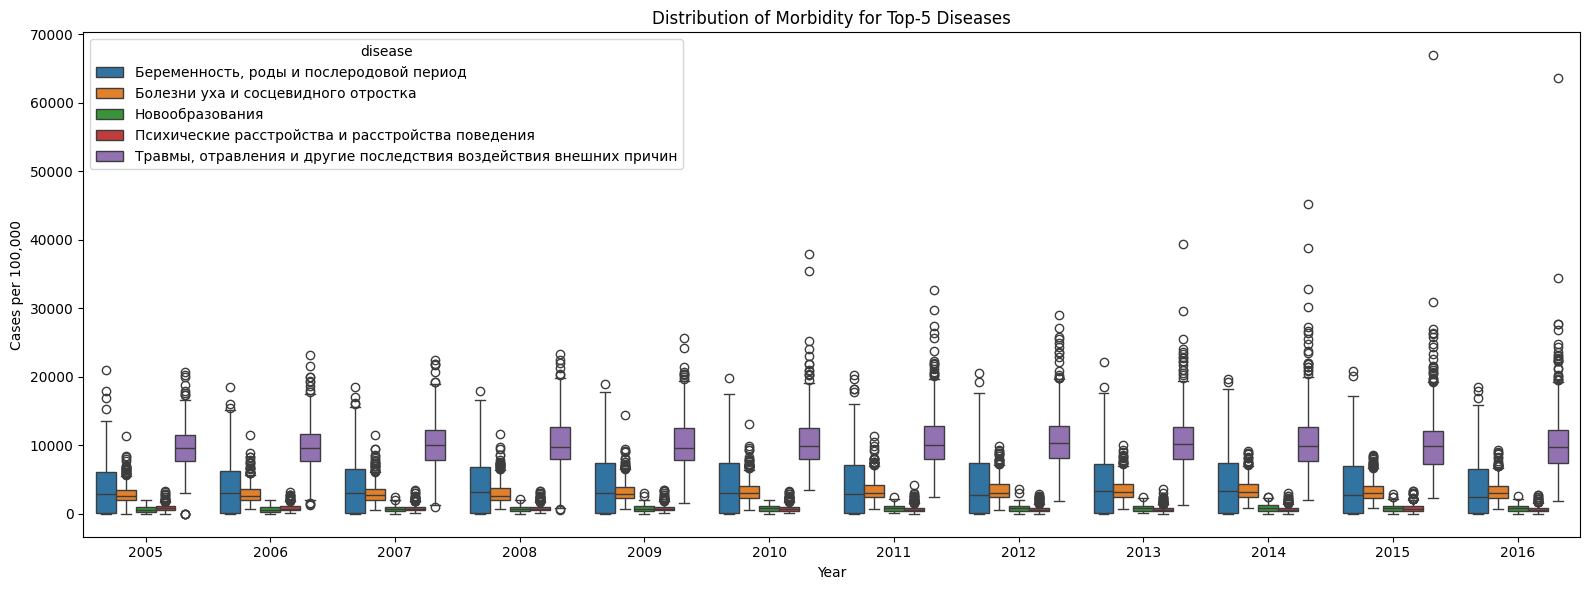

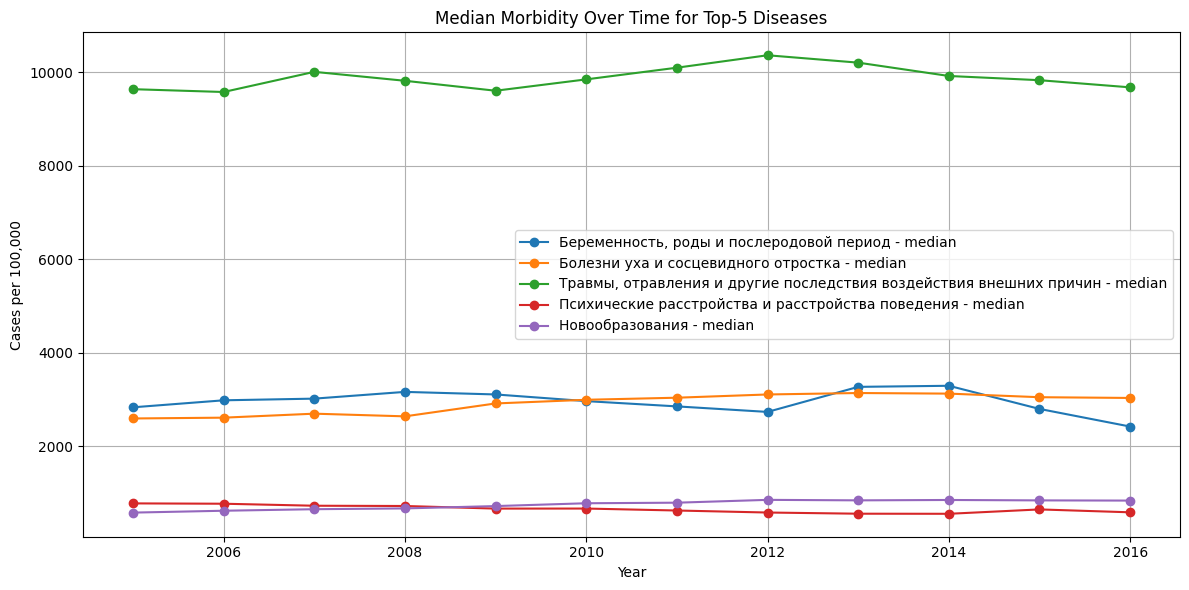

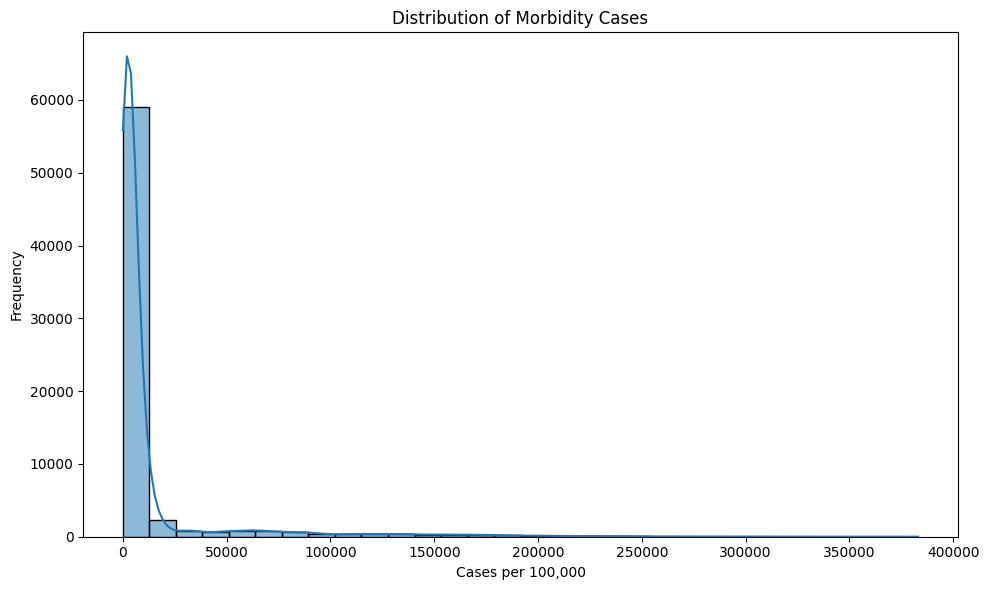

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
file_path = "../../outputs/standardized_datasets/morbidity_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()]

# 3. Convert cases to numeric
df["cases"] = pd.to_numeric(df["cases"], errors="coerce")

# 4. Check data types and missing values
print(df.info())
print("\nMissing values by column:\n", df.isnull().sum())

# 5. Number of unique regions, years, diseases, and age groups
print("\nNumber of unique regions:", df["region_standard"].nunique())
print("Number of unique years:", df["year"].nunique())
print("Number of unique diseases:", df["disease"].nunique())
print("Age groups:", df["age"].unique())

# 6. Check duplicates
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)

# 7. Summary statistics for cases
print("\nSummary statistics for cases:\n", df["cases"].describe())

# 8. Median values by year and disease
median_all = df.groupby(["year", "disease"])["cases"].median().unstack()

# 9. Boxplot by year for top-5 diseases
top_diseases = df["disease"].value_counts().head(5).index.tolist()
df_top = df[df["disease"].isin(top_diseases)]

plt.figure(figsize=(16,6))
sns.boxplot(x="year", y="cases", hue="disease", data=df_top)
plt.title("Distribution of Morbidity for Top-5 Diseases")
plt.xlabel("Year")
plt.ylabel("Cases per 100,000")
plt.tight_layout()
plt.show()

# 10. Median trends over time
plt.figure(figsize=(12,6))
for diag in top_diseases:
    med = median_all[diag].dropna()
    plt.plot(med.index, med.values, marker="o", label=f"{diag} - median")

plt.title("Median Morbidity Over Time for Top-5 Diseases")
plt.xlabel("Year")
plt.ylabel("Cases per 100,000")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 11. Distribution of cases
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="cases", bins=30, kde=True)
plt.title("Distribution of Morbidity Cases")
plt.xlabel("Cases per 100,000")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# EDA of `morbidity_standardized.csv`

## Data Description
- The dataset contains 68,041 observations across 85 regions.
- Time coverage: 2005–2016.
- Includes 19 disease categories and 4 age groups.

---

## Data Types
- All variables are correctly formatted.
- The `cases` column was converted to float.

---

## Missing Values
- No missing values were detected.

---

## Duplicates
- No duplicate records were found.

---

## Summary Statistics
- Mean: ~13,200 cases  
- Median: ~3,011 cases  
- Minimum: 0  
- Maximum: ~383,126 cases  
- The distribution is highly skewed  

This large gap between mean and median indicates a strong right-skewed distribution, driven by a small number of extremely high values.

---

## Visual Analysis
- **Boxplots by year (top-5 diseases)** show substantial variability and the presence of extreme values.  
- **Median trend plots** illustrate how morbidity evolves over time across major diseases.  
- **Distribution plots** confirm a heavy-tailed distribution with most observations concentrated at lower levels.  

---

## Interpretation
- The strong variability across diseases, regions, and age groups suggests significant heterogeneity in health conditions.  
- Extremely high values may reflect concentrated outbreaks or systemic differences in healthcare and reporting.  
- The skewed distribution indicates that a small number of regions or diseases dominate the overall statistics.  

These characteristics make morbidity an important feature for identifying structurally different regions.

---

## Conclusion
The dataset is clean and suitable for further analysis.

Due to its high variability and multidimensional structure (disease × age × region), morbidity data is expected to contribute meaningfully to clustering by capturing differences in regional health conditions.

In [3]:
df.to_csv("../../data/clean/morbidity_AfterEDA.csv", index=False)